# MARSIS: Radar Subsurface Analysis of Noctis Mons, Mars
## Radargram Extraction, Dielectric Constant Estimation & Compositional Modelling

**Author:** *FARIS BEG*

**Affiliation:** Institute of Planetary Research, Planetary Physics, German Aerospace Center (DLR), Berlin

**Description:**  
This notebook processes MARSIS (Mars Advanced Radar for Subsurface and Ionosphere Sounding) binary data files (NASA PDS Geosciences) to extract and analyse radar echoes over the Noctis Mons region. The radargram and cluttergram are loaded from PDS4 `.img` and `.xml` files, georeferenced using the associated `_geom.tab` file, and displayed as overlapping 2-D images. An interactive map allows three subsurface reflection points to be selected on an elevation (thickness) grid; their extracted elevations are used to compute the dielectric constant of the subsurface material. 
Compositional Modelling: The result is interpreted using a two-component dielectric mixing model (Stillman et al. 2010) to estimate the volume fractions of basalt and ice/void at those locations. A (supplementary) section provides a batch pipeline for scanning all MARSIS orbits in a folder and filtering those whose ground tracks fall within the Noctis Mons longitude window.

## Background: PDS4 XML Namespaces

The MARSIS data files follow the NASA PDS4 standard, where XML label files use **namespaces** to avoid tag-name collisions between different schemas. For example, a `<data_type>` tag under the PDS namespace (`http://pds.nasa.gov/pds4/pds/v1`) is distinct from one under a display namespace (`http://pds.nasa.gov/pds4/disp/v1`). The namespace dictionary `ns` defined in the loading cells below tells the XML parser which schema to look in when searching for each tag — analogous to calling a variable by its module prefix in Python (`np.array` vs `pd.array`).

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import geopandas as gpd
import matplotlib.image as mpimg

from datetime import datetime
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.rcParams.update({'font.size': 14})

def intensity_to_db(raw_intensity, scaling_factor, value_offset):
    """Convert raw integer pixel values to dB using the PDS4 calibration parameters."""
    return raw_intensity * scaling_factor + value_offset

## 2. Data Loading

### 2a. MOLA Context Map
A pre-saved MOLA global elevation grid is loaded to provide geographic context when overlaying the radar ground track.

### 2b. Radar data (`.img` + `_geom.tab` + `.xml`)
Each MARSIS orbit is distributed as three files:
- **`_uncorr_wind_b.img`** — binary image containing the 3-D radar data cube (Channel × Line × Sample)
- **`_geom.tab`** — CSV-like geometry file recording latitude, longitude, and UTC timestamp for each along-track measurement
- **`_uncorr_wind_b.xml`** — PDS4 XML label giving image dimensions, data type, and the calibration parameters (scaling factor, value offset) needed to convert raw integers to dB

The script parses the XML to extract dimensions and calibration, reads the geometry table for georeferencing, and loads the binary image. A fixed channel (channel 0 at frequency band 1) is sliced to produce the 2-D radargram `radar_image2d`.

The column corresponding to `target_latitude` is found with `np.argmin` on the latitude array — this gives the index of the measurement whose latitude is closest to the desired value.

Latitude range of the selected dataset (to verify validity for our ROI): -86.7357 to 12.9175
Longitude range of the selected dataset (to verify validity for our ROI): 0.1367 to 358.5959
Calibration: scaling_factor=0.4, value_offset=40.0
Data type: UnsignedByte
Image dimensions (obtained from XML metadata): channels=2, lines=2048, samples=1197
Radar image shape: (2048, 1197)
Column index 196 → lat = -6.3293°


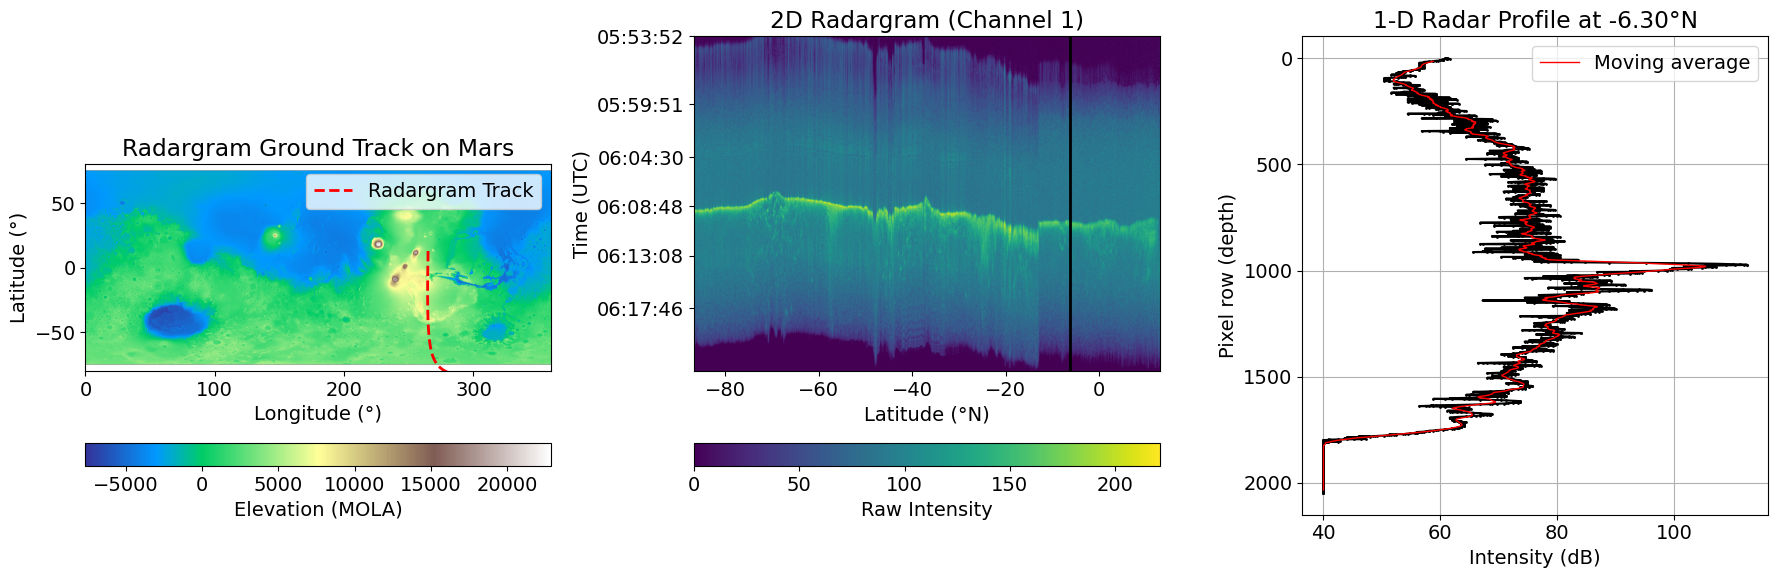

In [2]:
# MOLA context map 
mola_grid = np.load('MOLA_GLobalGrid_saved_lmax3000.npy')
lat_mola  = np.linspace(90, -90, mola_grid.shape[0])
lon_mola  = np.linspace(0, 360,  mola_grid.shape[1])

# File paths (NEEDS TO BE updated to user's local data directory) 
folder = r"C:\Users\DELL\Downloads\Literature Review_Internship_DLR - Evernote_files\ODE_Downloads\MARSIS_DATA_Noctis Centre\cartorder"

#Parses through the folder to search for the specified suffixes/extesnions
img_filename      = os.path.join(folder, "o_04884_uncorr_wind_b.img") #data file manually specified (from PDS Global Mars Map)
geom_tab_filename = os.path.join(folder, "o_04884_geom.tab")
xml_filename      = os.path.join(folder, "o_04884_uncorr_wind_b.xml")

target_latitude = -6.3  # latitude at which to extract the 1-D intensity profile

# STEP 1: Read geometry table (_geom.tab) 
# Column 3 = latitude, column 4 = longitude, column 2 = UTC timestamp
latitudes_tab  = np.loadtxt(geom_tab_filename, delimiter=',', usecols=3)
longitudes_tab = np.loadtxt(geom_tab_filename, delimiter=',', usecols=4)
lat_min, lat_max = latitudes_tab.min(), latitudes_tab.max()
lon_min, lon_max = longitudes_tab.min(), longitudes_tab.max()
print("Latitude range of the selected dataset (to verify validity for our ROI):", lat_min, "to", lat_max)
print("Longitude range of the selected dataset (to verify validity for our ROI):", lon_min, "to", lon_max)

# Convert timestamp strings to datetime objects and build elapsed-time array
timestamps    = np.genfromtxt(geom_tab_filename, delimiter=',', usecols=2, dtype=str)
datetime_objs = [datetime.strptime(t, "%Y-%m-%dT%H:%M:%S.%f") for t in timestamps]
t0            = datetime_objs[0]
time_seconds  = np.array([(dt - t0).total_seconds() for dt in datetime_objs])

# STEP 2: Parse radar XML label 
# see the note on XML namespaces above!
ns = {
    'pds':  'http://pds.nasa.gov/pds4/pds/v1',
    'disp': 'http://pds.nasa.gov/pds4/disp/v1'
}
tree = ET.parse(xml_filename)
root = tree.getroot()

array3d = root.find('.//pds:Array_3D_Image', ns) #searches for the specified rootword and extract calibration paramters
if array3d is None:
    raise ValueError("Could not find Array_3D_Image in XML.")

element_array  = array3d.find('pds:Element_Array', ns)
scaling_factor = float(element_array.find('pds:scaling_factor', ns).text)
value_offset   = float(element_array.find('pds:value_offset',   ns).text)
data_type_str  = element_array.find('pds:data_type', ns).text.strip()
print(f"Calibration: scaling_factor={scaling_factor}, value_offset={value_offset}")
print("Data type:", data_type_str)

dtype_map = {
    'UnsignedByte': np.uint8,  'Byte': np.int8,
    'int16': np.int16,         'int32': np.int32,
    'float32': np.float32,     'float64': np.float64,
}
dtype = dtype_map.get(data_type_str, np.float32)

# Extract Channel, Line, Sample dimensions from Axis_Array elements to constrcut the 2D radar plot from raw data
n_channels = nrows = ncols = None
for axis in array3d.findall('pds:Axis_Array', ns):
    name     = axis.find('pds:axis_name', ns).text.strip().lower()
    elements = int(axis.find('pds:elements', ns).text)
    if name == 'channel':  n_channels = elements
    elif name == 'line':   nrows = elements
    elif name == 'sample': ncols = elements

if None in (n_channels, nrows, ncols):
    raise ValueError("Could not find all three axes (Channel, Line, Sample) in XML.")
print(f"Image dimensions (obtained from XML metadata): channels={n_channels}, lines={nrows}, samples={ncols}")

# STEP 3: Load binary radar image and slice to 2-D using the channels, lines parameters above
raw_data      = np.fromfile(img_filename, dtype=dtype)
radar_3d      = raw_data.reshape((n_channels, nrows, ncols))
radar_image2d = radar_3d[1]  # Channel 1
radar_image_row_indices = np.arange(radar_image2d.shape[0])
print("Radar image shape:", radar_image2d.shape)

# STEP 4: Find column index for the target latitude 
col_idx          = int(np.argmin(np.abs(latitudes_tab - target_latitude))) #NOTE: each column maps to a latitudinal value!
selected_latitude = latitudes_tab[col_idx]
print(f"Column index {col_idx} → lat = {selected_latitude:.4f}°")

# Convert selected column to dB
radar_column_db = intensity_to_db(radar_image2d[:, col_idx], scaling_factor, value_offset)

# STEP 5: Plot — Mars map | 2D radargram | 1-D intensity profile 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Global Mars map with radar ground track
im0 = axes[0].imshow(mola_grid, cmap='terrain', origin='upper',
                     extent=[lon_mola.min(), lon_mola.max(), lat_mola.min(), lat_mola.max()])
axes[0].plot(longitudes_tab, latitudes_tab, color='red', linewidth=2,
             linestyle='--', label="Radargram Track")
axes[0].legend()
axes[0].set_title("Radargram Ground Track on Mars")
axes[0].set_xlabel("Longitude (°)")
axes[0].set_ylabel("Latitude (°)")
axes[0].set_ylim(-80,80)
fig.colorbar(im0, ax=axes[0], label="Elevation (MOLA)", orientation='horizontal')

# Panel 2: 2-D radargram image — x = latitude, y = UTC time
extent_rc = [lat_min, lat_max, datetime_objs[-1], datetime_objs[0]]
im1 = axes[1].imshow(radar_image2d, aspect='auto', extent=extent_rc, cmap='viridis')
axes[1].axvline(x=selected_latitude, color='black', linewidth=2)
axes[1].set_yticks(datetime_objs[::200])
axes[1].set_yticklabels([dt.strftime('%H:%M:%S') for dt in datetime_objs[::200]])
axes[1].set_xlabel("Latitude (°N)")
axes[1].set_ylabel("Time (UTC)")
axes[1].set_title("2D Radargram (Channel 1)")
fig.colorbar(im1, ax=axes[1], label="Raw Intensity", orientation='horizontal')

# Panel 3: 1-D intensity profile at target latitude with moving-average trend
axes[2].plot(radar_column_db, radar_image_row_indices,
             color='black', marker='o', markersize=1)
window_size = 30
moving_avg  = np.convolve(radar_column_db, np.ones(window_size)/window_size, mode='valid')
offset      = window_size // 2
axes[2].plot(moving_avg, np.arange(offset, radar_image2d.shape[0] - offset + 1),
             color='red', lw=1, label='Moving average')
axes[2].set_xlabel("Intensity (dB)")
axes[2].set_ylabel("Pixel row (depth)")
axes[2].set_title(f"1-D Radar Profile at {target_latitude:.2f}°N")
axes[2].invert_yaxis()
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

### 2c. Clutter simulation (`.clutter.img` + `.clutter.xml`)

The clutter file is a simulated 2-D image (Array_2D_Image in PDS4 terms) showing radar energy that would be returned from surface topography if the radar beam spread laterally. Comparing the real radargram against this simulation helps identify which reflectors are genuine subsurface echoes versus surface clutter.

Clutter data_type: UnsignedByte | unit: dB
Clutter image dimensions 9from the XMD metadata): lines=2048, samples=1197
Clutter image shape: (2048, 1197)


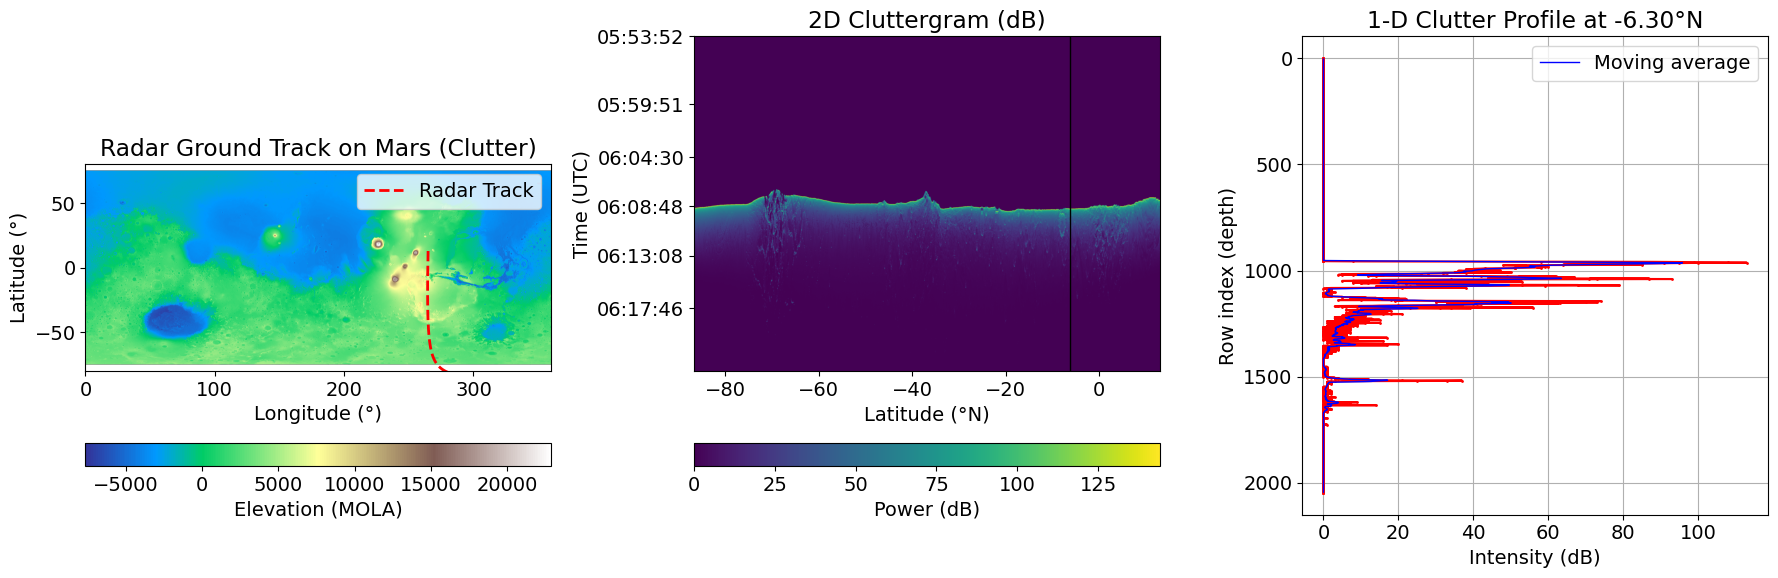

In [3]:
# File paths for the clutter simulation (modify based on local directory)
clutter_img_filename = os.path.join(folder, "o_04884_clutter.img")
clutter_xml_filename = os.path.join(folder, "o_04884_clutter.xml")

# Parse clutter XML (Array_2D_Image — no Channel axis) 
clutter_tree = ET.parse(clutter_xml_filename)
clutter_root = clutter_tree.getroot()

array2d = clutter_root.find('.//pds:Array_2D_Image', ns)
if array2d is None:
    raise ValueError("Could not find Array_2D_Image in clutter XML.")

elem_array    = array2d.find('pds:Element_Array', ns)
data_type_str = elem_array.find('pds:data_type', ns).text.strip()
unit_str      = elem_array.find('pds:unit',      ns).text.strip()  # should be 'dB'
print("Clutter data_type:", data_type_str, "| unit:", unit_str)

clutter_dtype = dtype_map.get(data_type_str, np.uint8)

# Extract Line and Sample dimensions as rows and columns same as before!
clutter_nrows = clutter_ncols = None
for axis in array2d.findall('pds:Axis_Array', ns):
    name     = axis.find('pds:axis_name', ns).text.strip().lower()
    elements = int(axis.find('pds:elements', ns).text)
    if name == 'line':    clutter_nrows = elements
    elif name == 'sample': clutter_ncols = elements

if clutter_nrows is None or clutter_ncols is None:
    raise ValueError("Could not find Line/Sample axes in clutter XML.")
print(f"Clutter image dimensions 9from the XMD metadata): lines={clutter_nrows}, samples={clutter_ncols}")

# Load binary clutter image 
clutter_raw   = np.fromfile(clutter_img_filename, dtype=clutter_dtype)
expected_size = clutter_nrows * clutter_ncols
if clutter_raw.size != expected_size:
    raise ValueError(f"Clutter size mismatch: got {clutter_raw.size}, expected {expected_size}")
clutter_image2d = clutter_raw.reshape((clutter_nrows, clutter_ncols))
print("Clutter image shape:", clutter_image2d.shape)

# we can align clutter baseline with radar using the value_offset from the radar XML
clutter_column_data    = clutter_image2d[:, col_idx]
clutter_column_aligned = clutter_column_data + value_offset

# Plot — Mars map | 2D cluttergram | 1-D clutter profile 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Global Mars map with radar ground track
im0 = axes[0].imshow(mola_grid, cmap='terrain', origin='upper',
                     extent=[lon_mola.min(), lon_mola.max(), lat_mola.min(), lat_mola.max()])
axes[0].plot(longitudes_tab, latitudes_tab, color='red', linewidth=2,
             linestyle='--', label="Radar Track")
axes[0].legend()
axes[0].set_title("Radar Ground Track on Mars (Clutter)")
axes[0].set_xlabel("Longitude (°)")
axes[0].set_ylabel("Latitude (°)")
axes[0].set_ylim (-80,80)
fig.colorbar(im0, ax=axes[0], label="Elevation (MOLA)", orientation='horizontal')

# Panel 2: 2-D cluttergram — x = latitude, y = UTC time
extent_rc = [lat_min, lat_max, datetime_objs[-1], datetime_objs[0]]
im1 = axes[1].imshow(clutter_image2d, aspect='auto', extent=extent_rc, cmap='viridis')
axes[1].axvline(x=selected_latitude, color='black', linewidth=1)
axes[1].set_yticks(datetime_objs[::200])
axes[1].set_yticklabels([dt.strftime('%H:%M:%S') for dt in datetime_objs[::200]])
axes[1].set_xlabel("Latitude (°N)")
axes[1].set_ylabel("Time (UTC)")
axes[1].set_title("2D Cluttergram (dB)")
fig.colorbar(im1, ax=axes[1], label="Power (dB)", orientation='horizontal')

# Panel 3: 1-D clutter profile at target latitude with moving-average trend
axes[2].plot(clutter_column_data, np.arange(clutter_nrows),
             color='red', marker='o', markersize=1)
window_size = 10
moving_avg  = np.convolve(clutter_column_data, np.ones(window_size)/window_size, mode='valid')
offset      = window_size // 2
axes[2].plot(moving_avg, np.arange(offset, clutter_nrows - offset + 1),
             color='blue', lw=1, label='Moving average')
axes[2].set_xlabel("Intensity (dB)")
axes[2].set_ylabel("Row index (depth)")
axes[2].set_title(f"1-D Clutter Profile at {target_latitude:.2f}°N")
axes[2].invert_yaxis()
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Radargram & Cluttergram Overlay

The radargram and cluttergram are displayed as overlapping images (viridis + inferno at 50% opacity) so that surface clutter returns can be visually distinguished from subsurface reflectors. The right panel shows the 1-D intensity profiles at the target latitude, with the clutter baseline shifted by `value_offset` to align both curves to the same dB scale.

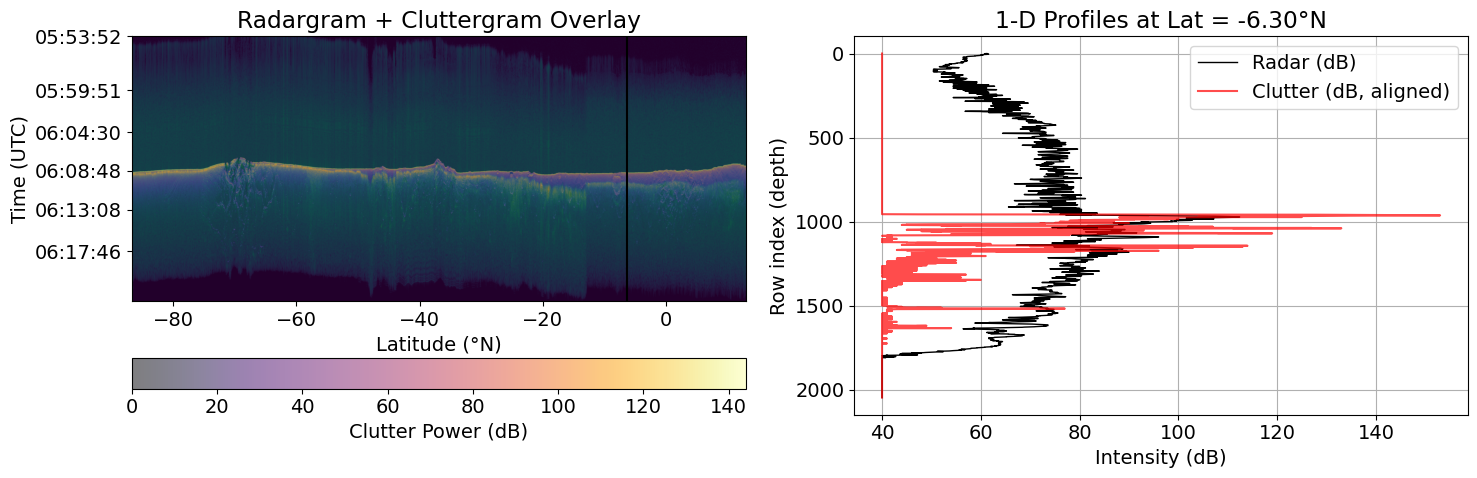

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left panel: radargram (opaque) with cluttergram overlaid at 50% opacity 
extent_rc = [lat_min, lat_max, datetime_objs[-1], datetime_objs[0]]

im_radar   = axes[0].imshow(radar_image2d,   aspect='auto', extent=extent_rc, cmap='viridis', alpha=1.0)
im_clutter = axes[0].imshow(clutter_image2d, aspect='auto', extent=extent_rc, cmap='inferno', alpha=0.5)

# Vertical line marking the target-latitude column
axes[0].axvline(x=latitudes_tab[col_idx], color='black', linewidth=1.5)
axes[0].set_yticks(datetime_objs[::200])
axes[0].set_yticklabels([dt.strftime('%H:%M:%S') for dt in datetime_objs[::200]])
axes[0].set_xlabel("Latitude (°N)")
axes[0].set_ylabel("Time (UTC)")
axes[0].set_title("Radargram + Cluttergram Overlay")
fig.colorbar(im_clutter, ax=axes[0], label="Clutter Power (dB)", orientation='horizontal')

# Right panel: 1-D intensity profiles at the target latitude 
nrows_plot = clutter_column_aligned.size
rows       = np.arange(nrows_plot)

axes[1].plot(radar_column_db,       rows, color='black', lw=1,   label="Radar (dB)")
axes[1].plot(clutter_column_aligned, rows, color='red',   alpha=0.7, label="Clutter (dB, aligned)")
axes[1].set_xlabel("Intensity (dB)")
axes[1].set_ylabel("Row index (depth)")
axes[1].set_title(f"1-D Profiles at Lat = {target_latitude:.2f}°N")
axes[1].invert_yaxis()  # row 0 at top (surface)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
fig.savefig("profiles_1D.png", dpi=600, bbox_inches='tight')
plt.show()

## 4. Interactive Subsurface Point Selection on the Thickness Grid

To extract dielectric constant values we need the **thickness** (surface-to-subsurface distance in metres) at locations where the radar clearly resolves a subsurface reflection. This section uses an interactive map to select those points precisely.

**How it works:**
- The left figure shows the thickness grid (obrained from subtracting Interpolated base surface from the present-day fractured topography)  with the MARSIS ground track overlaid.
- The right figure shows the radargram+clutter overlay for the same orbit (same dataset overliad above).
- A third figure (2×2 grid) fills in individual intensity profiles (retrieved from XML metadata and calibrated for intensity values) and their mean as points are clicked.

Clicking on any point along the track in the left figure marks it with a cyan dot, draws a vertical dashed line on the radargram at the corresponding latitude, and extracts the 1-D radar intensity profile for that column.

**Three clicks are needed.** Once we have clicked three times:
1. The `elevation_values` list will contain our three thickness (elevation data) readings.
2. To switch back to inline mode so we can visulaize the results within this notebook, we run the `%matplotlib inline`.
3. All subsequent cells (epsilon calculation, mixing model) will use those values automatically.

In [21]:
%matplotlib qt

# Load thickness and DEM grids from the previous notebook
grid_noctis     = np.load('grid_noctis.npy')
difference_grid = np.load('difference_grid.npy')

# Load shapefiles to build the coordinate mesh for the thickness grid
base_layer   = gpd.read_file(r"C:\Users\DELL\Downloads\Volume and Interpolation _Project_layers\elevations_2\base elevations_2.shp")
raised_layer = gpd.read_file(r"C:\Users\DELL\Downloads\Volume and Interpolation _Project_layers\elevations_2\raised elevations_2.shp")

x_b = base_layer['X'].values + 360
y_b = base_layer['Y'].values

grid_x_b, grid_y_b = np.meshgrid(
    np.linspace(x_b.min(), x_b.max(), difference_grid.shape[1]),
    np.linspace(y_b.min(), y_b.max(), difference_grid.shape[0])
)
x_min, x_max = grid_x_b.min(), grid_x_b.max()
y_min, y_max = grid_y_b.min(), grid_y_b.max()

Ny, Nx = difference_grid.shape
disp_grid = difference_grid[::-1, :]  # flip for display so north is at the top

# Figure 1: thickness grid with radar track — click here to select points
fig, ax0 = plt.subplots(figsize=(8, 6))
im0 = ax0.imshow(disp_grid, cmap='terrain', origin='upper',
                 extent=[x_min, x_max, y_min, y_max], aspect='auto')
ax0.contour(grid_x_b, grid_y_b, grid_noctis[::-1], levels=2, colors='k', origin='upper')
ax0.plot(longitudes_tab, latitudes_tab, color='red', linewidth=2,
         linestyle='--', label="Radargram Track")
ax0.set_title("Radargram track over 'thickness Grid'")
ax0.set_xlabel("Longitude (°E)")
ax0.set_ylabel("Latitude (°N)")
ax0.set_xlim(x_min, x_max)
ax0.set_ylim(y_min, y_max)
ax0.legend(loc='upper right')
fig.colorbar(im0, ax=ax0, label="Thickness (m)")
plt.tight_layout()

# Figure 2: radargram + cluttergram overlay
fig1, ax1 = plt.subplots(figsize=(8, 6))
extent_rc = [lat_min, lat_max, datetime_objs[-1], datetime_objs[0]]
ax1.imshow(radar_image2d,   aspect='auto', extent=extent_rc, cmap='viridis')
ax1.imshow(clutter_image2d, aspect='auto', extent=extent_rc, cmap='inferno', alpha=0.5)
ax1.set_title("2D Radargram + Clutter overlay")
ax1.set_xlabel("Latitude (°N)")
ax1.set_ylabel("Time (UTC)")
ax1.set_yticks(datetime_objs[::200])
ax1.set_yticklabels([dt.strftime('%H:%M:%S') for dt in datetime_objs[::200]])
fig1.colorbar(ax1.images[1], ax=ax1, label="Intensity (dB)", orientation='horizontal')
plt.tight_layout()

# Figure 3: individual profiles + mean (2x2 grid, fills on each click)
profile_fig, profile_axes = plt.subplots(2, 2, figsize=(12, 8))
profile_axes = profile_axes.flatten()
profile_fig.suptitle("Intensity profiles at selected locations", fontsize=13, y=0.98)
profile_fig.subplots_adjust(top=0.88, hspace=0.55, wspace=0.35)

profile_counter       = 0
profiles_list         = []
clutter_profiles_list = []
elevation_values      = []  # thickness values extracted from the grid at each click
selected_lats_list    = []  # nearest track latitude for each click — used to re-plot later
selected_lons_list    = []  # nearest track longitude for each click — used to re-plot later
clicked_lons_map      = []  # raw clicked longitude on the map — for the cyan markers
clicked_lats_map      = []  # raw clicked latitude on the map — for the cyan markers

def onclick(event):
    global profile_counter, profiles_list, clutter_profiles_list, elevation_values
    global selected_lats_list, selected_lons_list, clicked_lons_map, clicked_lats_map

    if event.inaxes is not ax0:
        return

    click_lon, click_lat = event.xdata, event.ydata
    if click_lon is None or click_lat is None:
        return

    print(f"Clicked at lon={click_lon:.4f}, lat={click_lat:.4f}")

    # Map click coordinates to array indices
    col      = np.clip(int((click_lon - x_min) / (x_max - x_min) * Nx), 0, Nx - 1)
    disp_row = np.clip(int((y_max - click_lat) / (y_max - y_min) * Ny), 0, Ny - 1)
    orig_row = (Ny - 1) - disp_row  # convert displayed row back to original array row

    elevation = difference_grid[orig_row, col]
    elevation_values.append(elevation)
    clicked_lons_map.append(click_lon)
    clicked_lats_map.append(click_lat)
    print(f"  -> Extracted difference_grid[{orig_row},{col}] = {elevation:.4f}")

    # Mark the clicked point on the thickness map
    ax0.plot(click_lon, click_lat, marker='o', color='cyan', markersize=6, zorder=4)
    fig.canvas.draw_idle()

    # Find nearest point on the radar ground track
    dist         = np.sqrt((longitudes_tab - click_lon)**2 + (latitudes_tab - click_lat)**2)
    nearest_idx  = np.argmin(dist)
    selected_lat = latitudes_tab[nearest_idx]
    selected_lon = longitudes_tab[nearest_idx]
    selected_lats_list.append(selected_lat)
    selected_lons_list.append(selected_lon)
    print(f"  -> Nearest track point: lat={selected_lat:.4f}, lon={selected_lon:.4f}")

    # Draw vertical dashed line on the radargram at the selected latitude
    ax1.axvline(x=selected_lat, color='black', linestyle='--', linewidth=1.5)
    fig1.canvas.draw_idle()  # refresh the radargram figure so the line appears

    # Extract 1-D radar and clutter profiles at this column
    radar_db   = intensity_to_db(radar_image2d[:, nearest_idx], scaling_factor, value_offset)
    clutter_db = clutter_image2d[:, nearest_idx]

    if profile_counter < 3:
        profiles_list.append(radar_db)
        clutter_profiles_list.append(clutter_db)

        axp = profile_axes[profile_counter]
        axp.plot(radar_db, radar_image_row_indices,
                 color='blue', marker='o', markersize=1, label="Radar")
        axp.set_xlabel("Intensity (dB)")
        axp.set_ylabel("Pixel Depth")
        axp.set_title(f"lat={selected_lat:.2f}°, lon={selected_lon:.2f}°", fontsize=9)
        axp.invert_yaxis()
        axp.grid(True)
        axp.legend(loc='upper right')
        profile_counter += 1
        profile_fig.canvas.draw_idle()
    else:
        print("  -> 3 profiles already collected.")

    # Update mean profile in the 4th subplot after every click
    if profiles_list:
        mean_radar = np.mean(profiles_list, axis=0)
        axm = profile_axes[3]
        axm.clear()
        axm.plot(mean_radar, radar_image_row_indices,
                 color='black', marker='o', markersize=1, label="Mean Radar")
        axm.set_xlabel("Intensity (dB)")
        axm.set_ylabel("Pixel Depth")
        axm.set_title("Mean Radar Profile")
        axm.invert_yaxis()
        axm.grid(True)
        axm.legend(loc='upper right')
        profile_fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_press_event', onclick)
plt.show()

# Once you have clicked three times, run the next cell to switch back to inline mode.

Clicked at lon=264.6257, lat=-5.2582
  -> Extracted difference_grid[130,32] = 5305.5525
  -> Nearest track point: lat=-5.2171, lon=264.6200
Clicked at lon=264.6061, lat=-6.4037
  -> Extracted difference_grid[92,32] = 4926.7686
  -> Nearest track point: lat=-6.4217, lon=264.6066
Clicked at lon=264.5866, lat=-7.5091
  -> Extracted difference_grid[55,32] = 3244.8466
  -> Nearest track point: lat=-7.5239, lon=264.5953


Elevation values collected (m): [np.float64(5305.552451220374), np.float64(4926.768611646636), np.float64(3244.846614467946)]
Number of profiles collected: 3


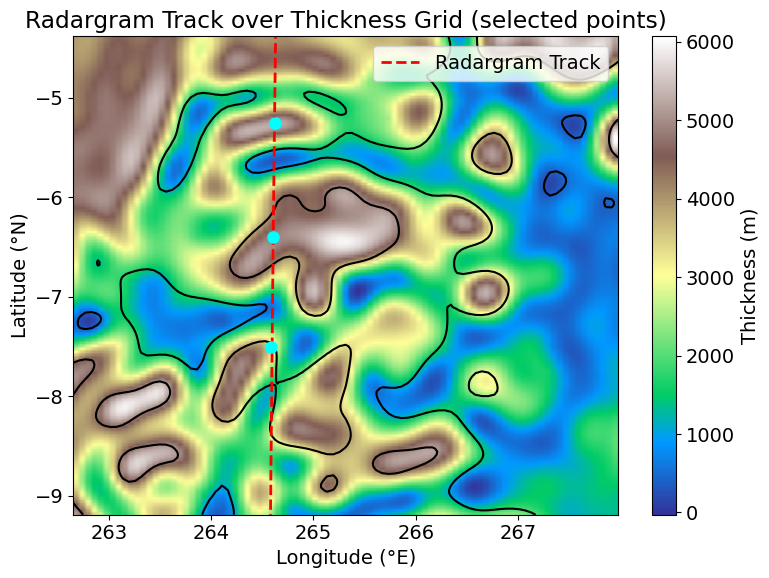

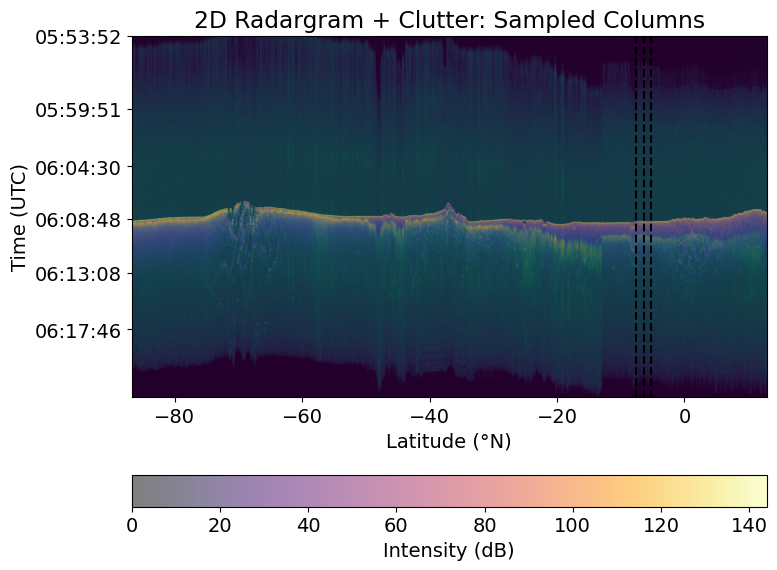

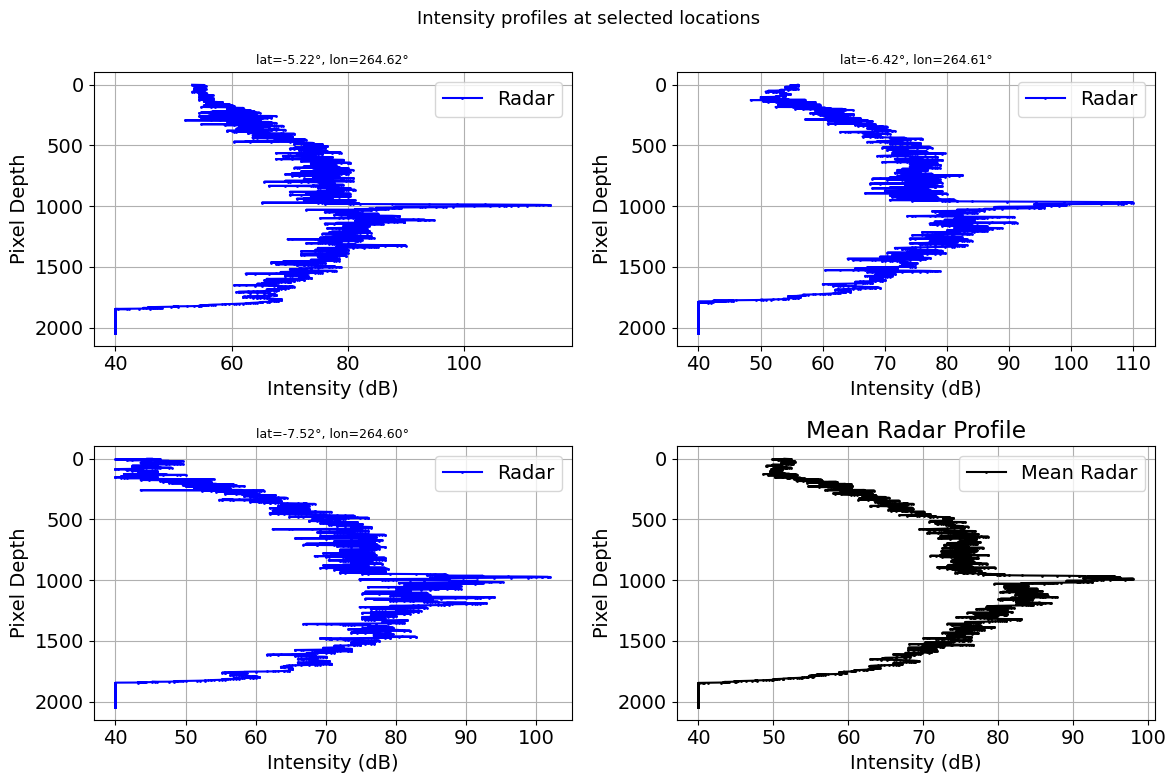

In [23]:
# Run this cell after clicking three times in the interactive window above.
# It switches back to inline mode and re-draws all three figures so the results
# are permanently visible in the notebook.
%matplotlib inline

print('Elevation values collected (m):', elevation_values)
print('Number of profiles collected:', len(profiles_list))

# Re-draw Figure 1: thickness grid with the clicked points marked
fig, ax0 = plt.subplots(figsize=(8, 6))
im0 = ax0.imshow(difference_grid[::-1, :], cmap='terrain', origin='upper',
                 extent=[x_min, x_max, y_min, y_max], aspect='auto')
ax0.contour(grid_x_b, grid_y_b, grid_noctis[::-1], levels=2, colors='k', origin='upper')
ax0.plot(longitudes_tab, latitudes_tab, color='red', linewidth=2,
         linestyle='--', label="Radargram Track")
for clon, clat in zip(clicked_lons_map, clicked_lats_map):
    ax0.plot(clon, clat, marker='o', color='cyan', markersize=8, zorder=4)
ax0.set_title("Radargram Track over Thickness Grid (selected points)")
ax0.set_xlabel("Longitude (°E)")
ax0.set_ylabel("Latitude (°N)")
ax0.set_xlim(x_min, x_max)
ax0.set_ylim(y_min, y_max)
ax0.legend(loc='upper right')
fig.colorbar(im0, ax=ax0, label="Thickness (m)")
plt.tight_layout()
plt.show()

# Re-draw Figure 2: radargram + clutter with vertical lines at each selected latitude
fig1, ax1 = plt.subplots(figsize=(8, 6))
extent_rc = [lat_min, lat_max, datetime_objs[-1], datetime_objs[0]]
ax1.imshow(radar_image2d,   aspect='auto', extent=extent_rc, cmap='viridis')
ax1.imshow(clutter_image2d, aspect='auto', extent=extent_rc, cmap='inferno', alpha=0.5)
for slat in selected_lats_list:
    ax1.axvline(x=slat, color='black', linestyle='--', linewidth=1.5)
ax1.set_title("2D Radargram + Clutter: Sampled Columns")
ax1.set_xlabel("Latitude (°N)")
ax1.set_ylabel("Time (UTC)")
ax1.set_yticks(datetime_objs[::200])
ax1.set_yticklabels([dt.strftime('%H:%M:%S') for dt in datetime_objs[::200]])
fig1.colorbar(ax1.images[1], ax=ax1, label="Intensity (dB)", orientation='horizontal')
plt.tight_layout()
plt.show()

# Re-draw Figure 3: individual profiles + mean
profile_fig, profile_axes = plt.subplots(2, 2, figsize=(12, 8))
profile_axes = profile_axes.flatten()
profile_fig.suptitle("Intensity profiles at selected locations", fontsize=13, y=0.98)
profile_fig.subplots_adjust(top=0.88, hspace=0.55, wspace=0.35)

for i, (radar_db, slat, slon) in enumerate(zip(profiles_list, selected_lats_list, selected_lons_list)):
    axp = profile_axes[i]
    axp.plot(radar_db, radar_image_row_indices, color='blue', marker='o', markersize=1, label="Radar")
    axp.set_xlabel("Intensity (dB)")
    axp.set_ylabel("Pixel Depth")
    axp.set_title(f"lat={slat:.2f}°, lon={slon:.2f}°", fontsize=9)
    axp.invert_yaxis()
    axp.grid(True)
    axp.legend(loc='upper right')

mean_radar = np.mean(profiles_list, axis=0)
axm = profile_axes[3]
axm.plot(mean_radar, radar_image_row_indices, color='black', marker='o', markersize=1, label="Mean Radar")
axm.set_xlabel("Intensity (dB)")
axm.set_ylabel("Pixel Depth")
axm.set_title("Mean Radar Profile")
axm.invert_yaxis()
axm.grid(True)
axm.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Height Estimation & Dielectric Constant Calculation

$$\varepsilon = \left( \frac{c \cdot t}{2H} \right)^2$$

where $c$ is the speed of light (3×10⁸ m/s), $t$ is the two-way travel time derived from the pixel separation between the surface and subsurface echoes, and $H$ is the physical thickness at the same location from the thickness grid.

The pixel count is measured from the mean intensity profile: the surface echo (highest intensity near the top) and the subsurface reflection are identified visually, and the pixel separation is multiplied by the per-pixel time step (0.35714 µs) to get the two-way travel time.

In [24]:
# Apparent thickness from pixel count 
pixel_count = 1138 - 990   # pixel separation between surface and subsurface echoes
time_step   = 0.35714e-6   # time represented by one pixel row (microseconds → seconds)
c           = 3e8           # speed of light (m/s)

time_delay_radar_sec = pixel_count * time_step
height_apparent = (c * time_delay_radar_sec) / 2  # two-way travel time correction
print("Apparent surface-to-subsurface thickness (km):", height_apparent / 1000)

# Dielectric constant from each sampled elevation 
time   = time_step * pixel_count
H      = np.array(elevation_values)  # physical thicknesses from the thickness grid (m)
epsilon_values = ((c * time) / (2 * H))**2
mean_epsilon   = np.mean(epsilon_values)
std_dev        = np.std(epsilon_values, ddof=1)  # sample standard deviation

print("Epsilon values at each sampled point:", epsilon_values)
print(f"Mean epsilon: {mean_epsilon:.4f}  ±  {std_dev:.4f} (1σ)")

Apparent surface-to-subsurface thickness (km): 7.928508
Epsilon values at each sampled point: [2.23316963 2.58975456 5.97027853]
Mean epsilon: 3.5977  ±  2.0624 (1σ)


## 7. Dielectric Mixing Model

The computed mixture dielectric constant is interpreted using the empirical mixing law of Stillman et al. for a two-component system:

$$\left(\varepsilon_{\text{mix}}\right)^{1/\gamma} = \phi_{\text{basalt}}\left(\varepsilon_{\text{basalt}}\right)^{1/\gamma} + \left(1 - \phi_{\text{basalt}}\right)\left(\varepsilon_{\text{second}}\right)^{1/\gamma}$$

with $\gamma = 2.7$ (sand-ice mixture exponent). Rearranging gives:

$$\phi_{\text{basalt}} = \frac{\varepsilon_{\text{mix}}^{1/\gamma} - \varepsilon_{\text{second}}^{1/\gamma}}{\varepsilon_{\text{basalt}}^{1/\gamma} - \varepsilon_{\text{second}}^{1/\gamma}}$$

Two scenarios for the second component are evaluated: **ice** ($\varepsilon = 3$) and **void** ($\varepsilon = 1$). The basalt dielectric constant is fixed at $\varepsilon_{\text{basalt}} = 6$, consistent with laboratory measurements for dry Martian basalt at 50 MHz [Stillman et al.; laboratory range 1.8–7.6].

Using mean_epsilon = 3.5977, basalt_value = 6
  Second component ε=3: φ_basalt=0.2378, φ_second=0.7622
  Second component ε=1: φ_basalt=0.6442, φ_second=0.3558


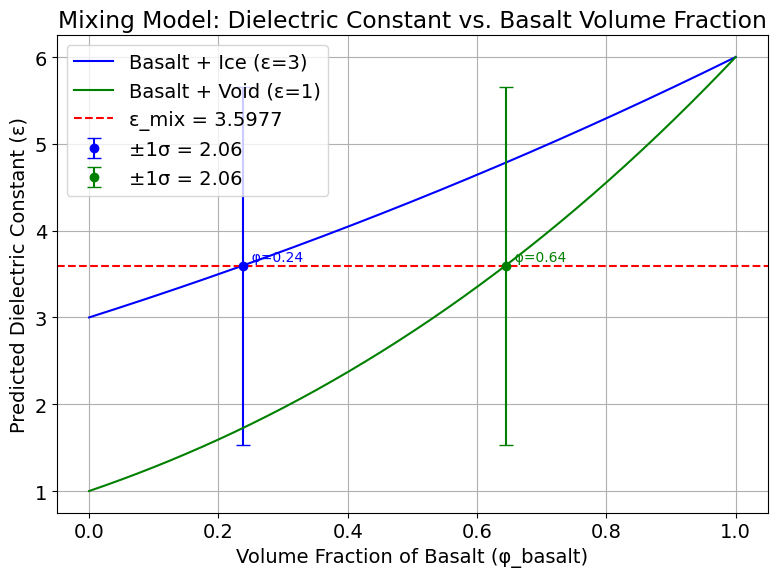

In [25]:
# Mixing model parameters 
gamma        = 2.7   # Stillman et al. empirical exponent for sand-ice mixture
basalt_value = 6     # Dry Martian basalt dielectric constant (justified: ε = 6)
second_values = [3, 1]  # Second component: ice (ε=3) or void (ε=1)

C = mean_epsilon  ** (1.0 / gamma)  # mixture term
A = basalt_value  ** (1.0 / gamma)  # basalt term

print(f"Using mean_epsilon = {mean_epsilon:.4f}, basalt_value = {basalt_value}")

phi_range = np.linspace(0, 1, 200)

def mixing_model(phi, eps_basalt, eps_second, gamma):
    """Predicted mixture dielectric constant as a function of basalt volume fraction."""
    return (phi * (eps_basalt**(1/gamma)) + (1 - phi) * (eps_second**(1/gamma)))**gamma

colors = ['blue', 'green']
labels = ['Ice (ε=3)', 'Void (ε=1)']

plt.figure(figsize=(8, 6))
for i, second in enumerate(second_values):
    B         = second ** (1.0 / gamma)
    phi_b     = (C - B) / (A - B)
    phi_s     = 1.0 - phi_b
    eps_curve = mixing_model(phi_range, basalt_value, second, gamma)

    if 0 <= phi_b <= 1:
        print(f"  Second component ε={second}: φ_basalt={phi_b:.4f}, φ_second={phi_s:.4f}")
    else:
        print(f"  Second component ε={second}: solution outside [0,1]")

    plt.plot(phi_range, eps_curve, color=colors[i], label=f'Basalt + {labels[i]}')
    plt.errorbar(phi_b, mean_epsilon, yerr=std_dev, fmt='o', color=colors[i],
                 capsize=5, label=f'±1σ = {std_dev:.2f}')
    plt.text(phi_b, mean_epsilon + 0.05, f'  φ={phi_b:.2f}', color=colors[i], fontsize=10)

plt.axhline(mean_epsilon, color='red', linestyle='--', label=f'ε_mix = {mean_epsilon:.4f}')
plt.xlabel('Volume Fraction of Basalt (φ_basalt)')
plt.ylabel('Predicted Dielectric Constant (ε)')
plt.title('Mixing Model: Dielectric Constant vs. Basalt Volume Fraction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

  Ice: φ_basalt=0.2378, φ_second=0.7622
  Void: φ_basalt=0.6442, φ_second=0.3558


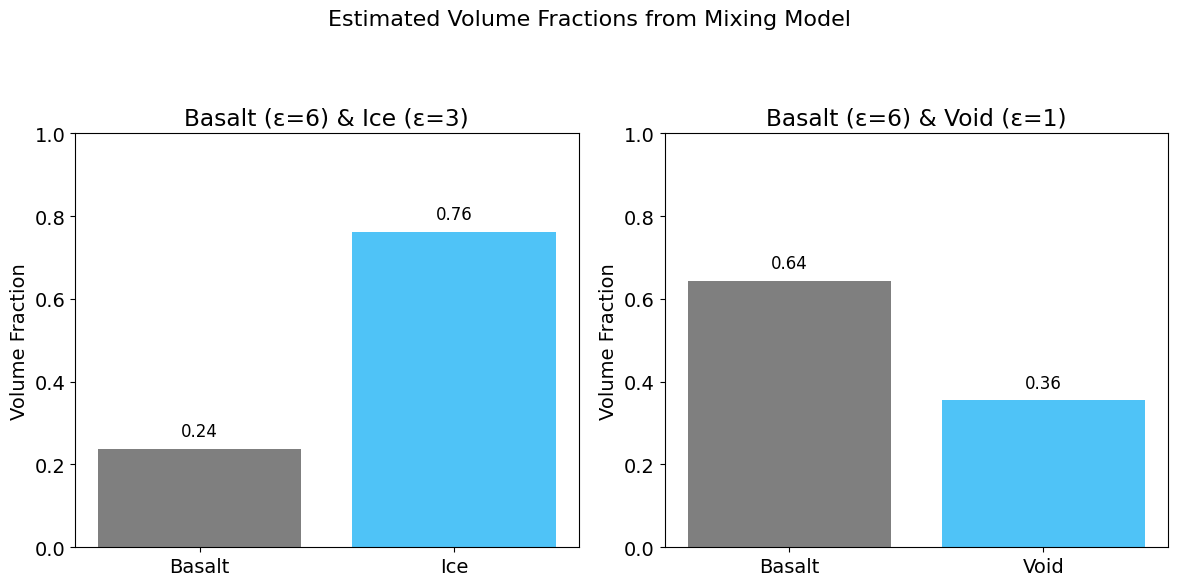

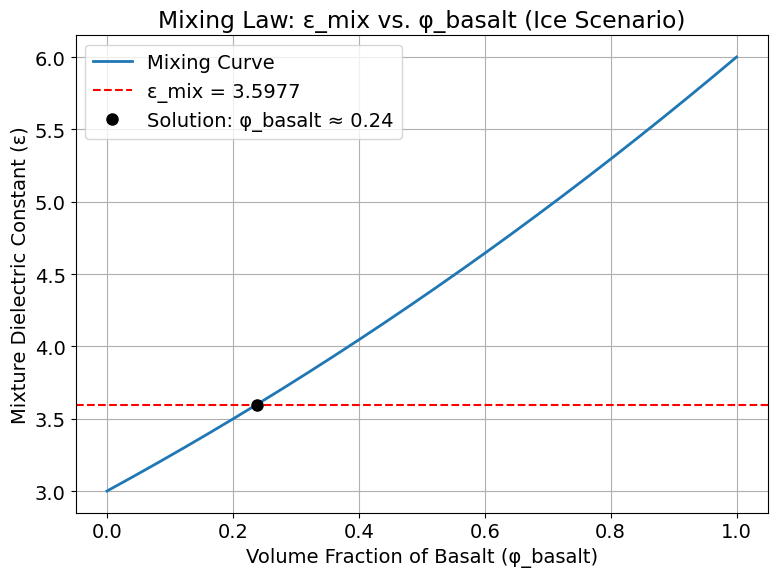

In [26]:
# Volume fraction bar chart and mixing curve 
epsilon_mix  = mean_epsilon
results      = {}

for second in second_values:
    B         = second ** (1.0 / gamma)
    phi_b     = (epsilon_mix**(1/gamma) - B) / (A - B)
    phi_s     = 1.0 - phi_b
    if 0 <= phi_b <= 1:
        comp = "Ice" if second == 3 else "Void"
        results[comp] = {'phi_basalt': phi_b, 'phi_second': phi_s, 'B': B}
        print(f"  {comp}: φ_basalt={phi_b:.4f}, φ_second={phi_s:.4f}")

# Bar chart of volume fractions
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 6))
if len(results) == 1:
    axes = [axes]

for ax, (comp, vals) in zip(axes, results.items()):
    fracs  = [vals['phi_basalt'], vals['phi_second']]
    colors_bar = ['#7f7f7f', '#4fc3f7']
    ax.bar(['Basalt', comp], fracs, color=colors_bar)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Volume Fraction")
    ax.set_title(f"Basalt (ε=6) & {comp} (ε={'3' if comp=='Ice' else '1'})")
    for i, v in enumerate(fracs):
        ax.text(i, v + 0.03, f"{v:.2f}", ha='center', fontsize=12)

fig.suptitle("Estimated Volume Fractions from Mixing Model", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Mixing curve for the ice scenario
if "Ice" in results:
    phi_b_ice    = results["Ice"]["phi_basalt"]
    phi_range_arr = np.linspace(0, 1, 200)
    eps_curve    = mixing_model(phi_range_arr, basalt_value, 3, gamma)

    fig2, ax2 = plt.subplots(figsize=(8, 6))
    ax2.plot(phi_range_arr, eps_curve, label="Mixing Curve", lw=2)
    ax2.axhline(epsilon_mix, color='red', linestyle='--', label=f"ε_mix = {epsilon_mix:.4f}")
    ax2.plot(phi_b_ice, epsilon_mix, 'ko', markersize=8, label=f"Solution: φ_basalt ≈ {phi_b_ice:.2f}")
    ax2.set_xlabel("Volume Fraction of Basalt (φ_basalt)")
    ax2.set_ylabel("Mixture Dielectric Constant (ε)")
    ax2.set_title("Mixing Law: ε_mix vs. φ_basalt (Ice Scenario)")
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

### Verification: Brute-Force Search

As a sanity check, the volume fraction is also found by stepping through φ in small increments and identifying the value that minimises the residual in the mixing equation. The result should match the analytical solution above.

In [27]:
eps_mix    = mean_epsilon
eps_basalt = 6
eps_ice    = 3

A_b = eps_basalt ** (1/gamma)
B_i = eps_ice    ** (1/gamma)
C_m = eps_mix    ** (1/gamma)

best_phi  = None
best_diff = float('inf')

for phi_b in np.linspace(0, 1, 1001):
    rhs  = phi_b * A_b + (1 - phi_b) * B_i
    diff = abs(C_m - rhs)
    if diff < best_diff:
        best_diff = diff
        best_phi  = phi_b

print(f"Brute-force φ_basalt = {best_phi:.4f}  (residual = {best_diff:.6f})")

Brute-force φ_basalt = 0.2380  (residual = 0.000075)



## 8. SUPPLEMENTARY (ADDITIONAL): Batch Data Pipeline: MARSIS Orbit Extraction for Noctis Longitude Window

This section implements a **file-matching and filtering pipeline** for processing multiple MARSIS orbits at once. Given a folder containing mixed `.png`, `.tab`, and other files from multiple orbits, the code:

1. Scans for all `_geom.tab` files and builds a mapping from orbit prefix to geometry file.
2. For each `.png` radargram image, locates its matching `.tab` file by prefix.
3. Reads the longitude extent and elapsed-time range from the `.tab` file.
4. **Filters** to only those orbits whose ground track overlaps the Noctis Mons longitude window (262.70°–269.56°, derived from the circular uplift radius calculated in the reconstruction notebook).
5. Plots each matching radargram with calibrated longitude and time axes.

The second cell then finds the **single orbit closest to a user-specified target longitude** — useful for quickly locating a specific radargram without manually inspecting every file.

In [ ]:
# Folder containing all MARSIS PNG and TAB files 
data_folder = r"C:\Users\DELL\Downloads\Literature Review_Internship_DLR - Evernote_files\ODE_Downloads\MARSIS_DATA_Noctis Centre\cartorder"

# Step 1: Build prefix → TAB file mapping 
# TAB files are named e.g. "o_17821_geom.tab"; prefix = "o_17821"
tab_files      = [f for f in os.listdir(data_folder) if f.lower().endswith('.tab')]
prefix_to_tab  = {}
for tab in tab_files:
    if '_geom' in tab:
        prefix = tab.split('_geom')[0]
    else:
        prefix = os.path.splitext(tab)[0]
    prefix_to_tab[prefix] = tab

# Step 2: List and sort all PNG radargram images 
png_files = sorted([f for f in os.listdir(data_folder) if f.lower().endswith('.png')])
print(f"Found {len(png_files)} PNG files")

# Noctis longitude filter window (from circular uplift radius calculation)
desired_lon_min = 262.70
desired_lon_max = 269.56

def extract_lon_time_extent_from_tab(tab_path):
    """Read a geom.tab file and return (min_lon, max_lon, min_time_s, max_time_s)."""
    lons, times = [], []
    try:
        with open(tab_path, 'r') as f:
            first_time = None
            for line in f:
                parts = line.strip().split(',')
                if len(parts) < 5:
                    continue
                try:
                    lons.append(float(parts[4].strip()))
                    t_obj = datetime.strptime(parts[2].strip(), "%Y-%m-%dT%H:%M:%S.%f")
                    if first_time is None:
                        first_time = t_obj
                    times.append((t_obj - first_time).total_seconds())
                except ValueError:
                    continue
        if not lons:
            return None, None, None, None
        return min(lons), max(lons), min(times), max(times)
    except Exception as e:
        print(f"Error reading {tab_path}: {e}")
        return None, None, None, None

# Step 3: Match each PNG to its TAB file, filter, and plot 
for png_file in png_files:
    matching_tab = None
    for prefix, tab in prefix_to_tab.items():
        if png_file.startswith(prefix):
            matching_tab = tab
            break

    if matching_tab is None:
        print(f"No matching TAB for {png_file} — skipping.")
        continue

    tab_path = os.path.join(data_folder, matching_tab)
    png_path = os.path.join(data_folder, png_file)

    min_lon, max_lon, min_time, max_time = extract_lon_time_extent_from_tab(tab_path)
    if min_lon is None:
        continue

    # Keep only orbits whose track overlaps the Noctis longitude window
    if max_lon < desired_lon_min or min_lon > desired_lon_max:
        continue

    img    = mpimg.imread(png_path)
    extent = [min_lon, max_lon, min_time, max_time]

    plt.figure(figsize=(12, 6))
    plt.imshow(img, aspect='auto', extent=extent, cmap='viridis')
    plt.colorbar(label="Signal Intensity")
    plt.title(f"MARSIS Radargram: {png_file}")
    plt.xlabel("Longitude (°)")
    plt.ylabel("Time Elapsed from First Record (s)  ←  depth proxy")
    plt.show()

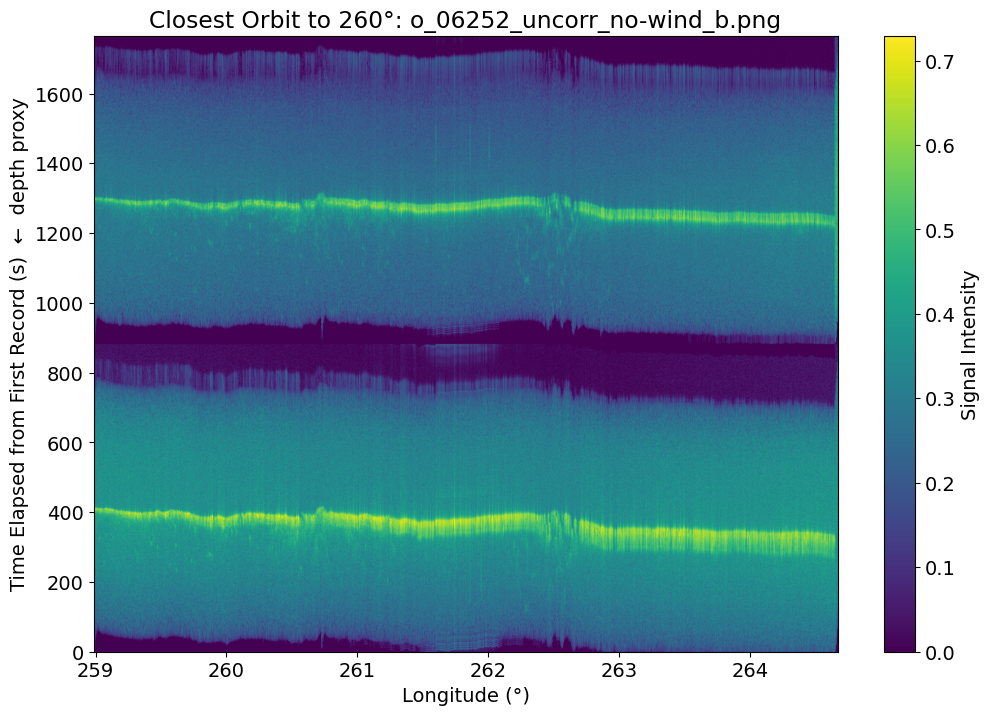

In [20]:
# Find the single orbit whose track is closest to a target longitude 
# Build a per-prefix listing of PNG files
png_by_prefix = {}
for png_file in png_files:
    for prefix in prefix_to_tab:
        if png_file.startswith(prefix):
            png_by_prefix.setdefault(prefix, []).append(png_file)
            break

target_lon      = 260  # desired longitude (°)
closest_dataset = None
closest_diff    = float('inf')

for prefix, png_list in png_by_prefix.items():
    tab_path = os.path.join(data_folder, prefix_to_tab[prefix])
    png_path = os.path.join(data_folder, png_list[0])

    min_lon, max_lon, min_time, max_time = extract_lon_time_extent_from_tab(tab_path)
    if min_lon is None:
        continue

    diff = abs(min_lon - target_lon)
    if diff < closest_diff:
        closest_diff    = diff
        closest_dataset = {
            'png_file': png_list[0], 'png_path': png_path,
            'min_lon': min_lon, 'max_lon': max_lon,
            'min_time': min_time, 'max_time': max_time
        }

if closest_dataset is None:
    print("No dataset found for the target longitude.")
else:
    img    = mpimg.imread(closest_dataset['png_path'])
    extent = [closest_dataset['min_lon'], closest_dataset['max_lon'],
              closest_dataset['min_time'], closest_dataset['max_time']]

    plt.figure(figsize=(12, 8))
    plt.imshow(img, cmap='viridis', aspect='auto', extent=extent)
    plt.colorbar(label="Signal Intensity")
    plt.title(f"Closest Orbit to {target_lon}°: {closest_dataset['png_file']}")
    plt.xlabel("Longitude (°)")
    plt.ylabel("Time Elapsed from First Record (s)  ←  depth proxy")
    plt.show()